# Chunk Perturbation: Load KL Curves, Plot, and Fit
This notebook loads precomputed KL(epsilon) curves saved by `scripts/collect_kl_curves.py` and produces per-layer combined KL vs epsilon plots and amplitude-vs-metric scatterplots. It also fits an inverse model a/x + b and compares it to independent exponentials using AIC/BIC, Vuong test, and 5-fold CV.

In [1]:
import os, json, numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from collections import defaultdict

model_name = 'deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B'
model_tag = model_name.replace('/', '-')
repo_root = Path.cwd().resolve().parents[0] if (Path.cwd()).exists() else Path.cwd().resolve()
annotated_path = repo_root / 'data' / f'annotated_data_{model_tag}.json'
kl_path = repo_root / 'data' / f'kl_curves_perturb_{model_tag}.json'
print('Loading:', kl_path)
with open(annotated_path,'r') as f: annotated = json.load(f)
with open(kl_path,'r') as f: payload = json.load(f)
examples = [ex for ex in annotated if ex.get('thought_anchor_sentence')]
curves_all = payload.get('curves', [])
epsilons = np.asarray(payload.get('epsilons', []), dtype=float)
byL = defaultdict(list)
for c in curves_all: byL[int(c.get('layer', -1))].append(c)
sorted(list(byL.keys())), len(curves_all), epsilons[:5] if epsilons.size>0 else epsilons

Loading: /home/cutterdawes/SteeringThoughtAnchors/data/kl_curves_perturb_deepseek-ai-DeepSeek-R1-Distill-Qwen-1.5B.json


([24], 533, array([0. , 0.5, 1. , 1.5, 2. ]))

<Figure size 640x480 with 0 Axes>

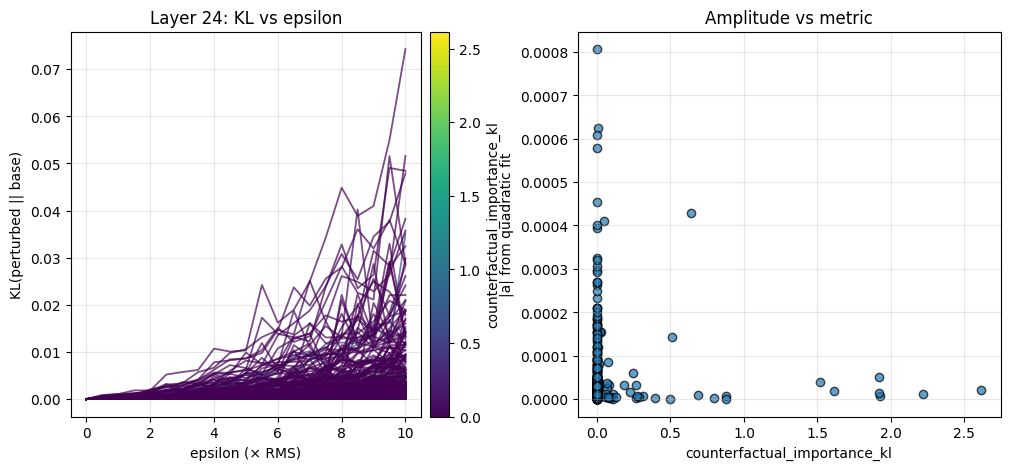

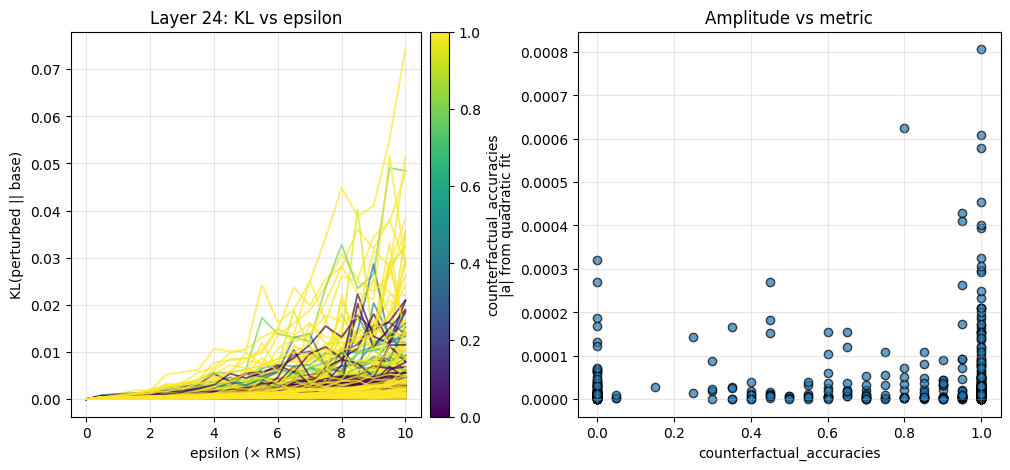

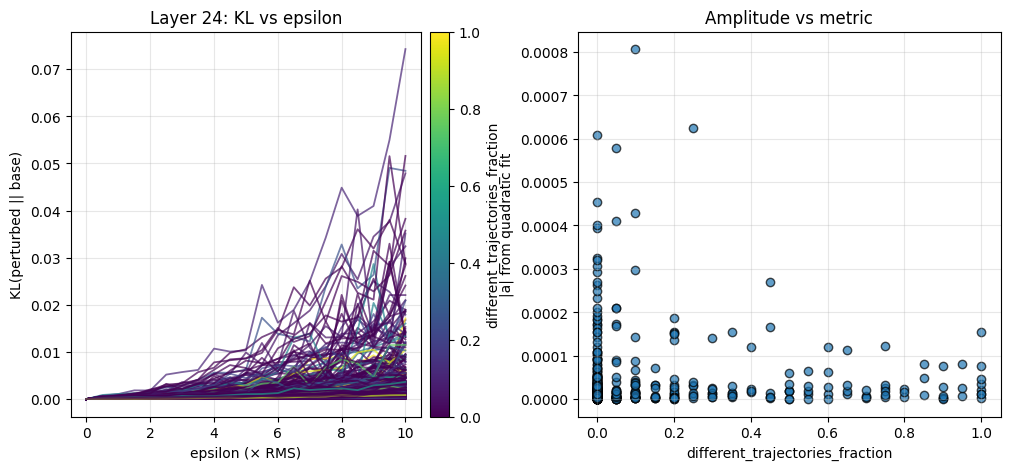

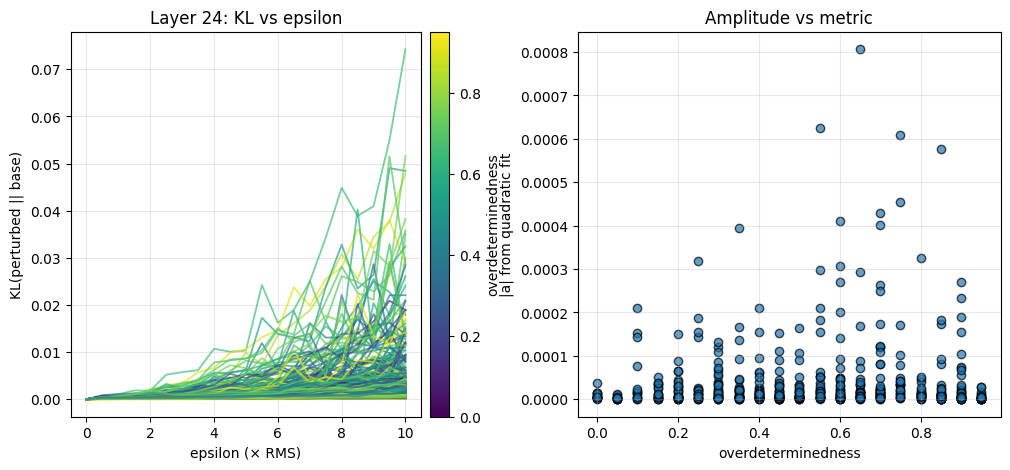

In [4]:
# Plot combined per-layer figures (KL vs epsilon and amplitude vs metric)
import numpy as np
from matplotlib.colors import Normalize

repo_root = Path.cwd().resolve().parents[0] if (Path.cwd()).exists() else Path.cwd().resolve()
import sys
sys.path.append(str(repo_root))

from utils import normalize_by_group

metric_key_to_label = {
    'kl': 'counterfactual_importance_kl',
    'acc': 'counterfactual_accuracies',
    'diff': 'different_trajectories_fraction',
    'over': 'overdeterminedness',
}

def _get_metric_from_example(ex, idx: int, metric_key: str) -> float:
    arr = ex.get(metric_key_to_label[metric_key], []) or []
    try: return float(arr[idx]) if idx < len(arr) else 0.0
    except Exception: return 0.0

def _fit_amp_quadratic(xs: np.ndarray, ys: np.ndarray) -> float:
    n = min(xs.size, ys.size)
    if n < 3: return np.nan
    try: return abs(float(np.polyfit(xs[:n], ys[:n], 2)[0]))
    except Exception: return np.nan

def plot_combined_per_layer(curves_for_layer: list, examples_list: list, x_values: np.ndarray, metric_key: str, L: int, save: bool = False, normalize_amp: bool = True):
    vals, amps, ex_keys = [], [], []
    for c in curves_for_layer:
        ex_i = int(c.get('example_index', 0)); ch_i = int(c.get('chunk_index', 0))
        vals.append(_get_metric_from_example(examples_list[ex_i], ch_i, metric_key))
        ex_keys.append(ex_i)
        ys = np.asarray(c.get('ys', []) or [], dtype=float)
        amps.append(_fit_amp_quadratic(np.asarray(x_values, dtype=float), ys))
    M = np.asarray(vals, dtype=float); A = np.asarray(amps, dtype=float)
    A_plot = np.asarray(normalize_by_group(ex_keys, A), dtype=float) if normalize_amp else A
    vmin, vmax = (0.0, (np.nanmax(M) if np.isfinite(np.nanmax(M)) else 1.0)) if metric_key != 'kl' else (0.0, (np.nanmax(M) if np.isfinite(np.nanmax(M)) else 0.01))
    norm = Normalize(vmin=vmin, vmax=max(vmin+1e-9, vmax)); cmap = plt.cm.viridis
    fig, axes = plt.subplots(1,2, figsize=(12,5)); ax0, ax1 = axes
    for c, m in zip(curves_for_layer, M):
        ys = np.asarray(c.get('ys', []) or [], dtype=float)
        n = min(len(x_values), len(ys))
        if n == 0: continue
        ax0.plot(x_values[:n], ys[:n], color=cmap(norm(m)), linewidth=1.3, alpha=0.7)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array(M)
    cb = fig.colorbar(sm, ax=ax0, pad=0.02); cb.set_label(metric_key_to_label[metric_key])
    ax0.set_xlabel('epsilon (× RMS)'); ax0.set_ylabel('KL(perturbed || base)'); ax0.set_title(f'Layer {L}: KL vs epsilon')
    ax0.grid(True, alpha=0.3)
    ax1.scatter(M, A_plot, edgecolor='black', alpha=0.7)
    ax1.set_xlabel(metric_key_to_label[metric_key]); ax1.set_ylabel(('normalized |a| (per example)' if normalize_amp else '|a| from quadratic fit'))
    ax1.set_title('Amplitude vs metric'); ax1.grid(True, alpha=0.3)

    
    
    # Optional save to data/figures when save=True
    if save:
        from pathlib import Path as _P
        _rr = _P.cwd().resolve().parents[0] if (_P.cwd()).exists() else _P.cwd().resolve()
        save_dir = _rr / 'data' / 'figures'
        try: save_dir.mkdir(parents=True, exist_ok=True)
        except Exception: pass
        base = f"perturb_{model_tag}"
        fname = f"{base}_{metric_key}_L{L}.png"
        try: fig.savefig(save_dir / fname, dpi=200, bbox_inches='tight')
        except Exception: pass
plt.tight_layout(); plt.show()

metrics = ['kl','acc','diff','over']
for L in sorted(byL.keys()):
    for mk in metrics:
        plot_combined_per_layer(byL[L], examples, epsilons, mk, L=L, save=True, normalize_amp=False)


In [ ]:
# Fit scatter with Frank copula (exponential marginals)
import numpy as np
from dataclasses import dataclass
from scipy.optimize import minimize
from scipy.special import debye

# Extract metric (X) and amplitude (Y) pairs

def _MA_from_curves(curves, examples, x_values, metric_key):
    vals = []; amps = []
    for c in curves:
        ex_i = int(c.get('example_index', 0)); ch_i = int(c.get('chunk_index', 0))
        arr = examples[ex_i].get({'kl':'counterfactual_importance_kl','acc':'counterfactual_accuracies','diff':'different_trajectories_fraction','over':'overdeterminedness'}[metric_key], []) or []
        v = float(arr[ch_i]) if ch_i < len(arr) else 0.0
        ys = np.asarray(c.get('ys', []) or [], dtype=float)
        n = min(len(x_values), len(ys))
        if n < 3: continue
        try:
            acoef = float(np.polyfit(x_values[:n], ys[:n], 2)[0])
        except Exception:
            continue
        vals.append(max(0.0, v)); amps.append(abs(acoef))
    X = np.asarray(vals, dtype=float)
    Y = np.asarray(amps, dtype=float)
    m = np.isfinite(X) & np.isfinite(Y) & (X >= 0) & (Y >= 0)
    return X[m], Y[m]

# Exponential marginals: lambda = 1/mean

def estimate_marginals(x, y):
    lam_x = 1.0 / max(np.mean(x), 1e-12)
    lam_y = 1.0 / max(np.mean(y), 1e-12)
    return lam_x, lam_y

# Frank copula log-density

def frank_log_copula_density(u, v, theta):
    u = np.clip(u, 1e-12, 1 - 1e-12)
    v = np.clip(v, 1e-12, 1 - 1e-12)
    if abs(theta) < 1e-8:
        return np.zeros_like(u)
    A = np.exp(-theta*u)
    B = np.exp(-theta*v)
    E = np.exp(-theta)
    num = theta * np.exp(-theta*(u+v)) * (1.0 - E)
    den = ((A - 1.0)*(B - 1.0) + (1.0 - E))**2
    den = np.clip(den, 1e-300, None)
    val = np.log(abs(theta)) - theta*(u+v) + np.log(1.0 - E) - 2.0*np.log( (A - 1.0)*(B - 1.0) + (1.0 - E) )
    return val

@dataclass
class FitReport:
    n: int
    lam_x: float
    lam_y: float
    theta: float
    ll_indep: float
    ll_total: float
    aic: float
    bic: float
    tau: float


def fit_frank_copula_expon(x, y):
    # Estimate marginals
    lam_x, lam_y = estimate_marginals(x, y)
    # Transform to uniforms
    u = 1.0 - np.exp(-lam_x * x)
    v = 1.0 - np.exp(-lam_y * y)
    u = np.clip(u, 1e-12, 1 - 1e-12)
    v = np.clip(v, 1e-12, 1 - 1e-12)

    # Marginal log-likelihoods (exponential)
    ll_marg = np.sum(np.log(lam_x) - lam_x*x) + np.sum(np.log(lam_y) - lam_y*y)

    # Optimize theta by maximizing copula log-likelihood
    def nll(th):
        th = float(th[0])
        llc = np.sum(frank_log_copula_density(u, v, th))
        return -llc

    res = minimize(nll, x0=np.array([0.5]), method='BFGS')
    theta = float(res.x[0])
    # Compute totals
    ll_cop = np.sum(frank_log_copula_density(u, v, theta))
    ll_total = float(ll_marg + ll_cop)
    # Independence (theta=0) => copula ll = 0
    ll_indep = float(ll_marg)
    n = len(x)
    k = 3  # lam_x, lam_y, theta
    aic = 2*k - 2*ll_total
    bic = k*np.log(max(n,1)) - 2*ll_total
    # Kendall's tau for Frank: tau = 1 + 4/theta * (D1(theta) - 1)
    if abs(theta) < 1e-8:
        tau = 0.0
    else:
        tau = 1.0 + (4.0/theta) * (debye(1, theta) - 1.0)
    return FitReport(n=n, lam_x=lam_x, lam_y=lam_y, theta=theta, ll_indep=ll_indep, ll_total=ll_total, aic=aic, bic=bic, tau=float(tau))

metrics = ['kl','acc','diff','over']
for mk in metrics:
    x, y = _MA_from_curves(curves, examples, betas if 'betas' in globals() else epsilons, mk)
    if len(x) < 8:
        print(f'[copula] {mk}: not enough points');
        continue
    rep = fit_frank_copula_expon(x, y)
    print(f"[copula] {mk}: n={rep.n} lam_x={rep.lam_x:.4g} lam_y={rep.lam_y:.4g} theta={rep.theta:.4g} | ll(indep)={rep.ll_indep:.3f} ll(fit)={rep.ll_total:.3f} AIC={rep.aic:.1f} BIC={rep.bic:.1f} tau={rep.tau:.3f}")


In [ ]:
# Scatter with 1/x on X and linear fit (y = a x + b) for kl and diff
import numpy as np
import matplotlib.pyplot as plt

metrics_plot = ['kl', 'diff']
fig, axes = plt.subplots(1, len(metrics_plot), figsize=(12,5))
if len(metrics_plot)==1:
    axes=[axes]
for ax, mk in zip(axes, metrics_plot):
    x, y = _MA_from_curves(curves, examples, betas if 'betas' in globals() else epsilons, mk)
    if len(x) < 3:
        ax.set_title(f'{mk}: not enough points'); ax.axis('off'); continue
    invx = 1.0 / np.clip(x, 1e-12, None)
    ax.scatter(invx, y, edgecolor='black', alpha=0.7)
    ax.set_xlabel('1 / ' + {'kl':'counterfactual_importance_kl','diff':'different_trajectories_fraction'}[mk])
    ax.set_ylabel('|a| from quadratic fit')
    # Linear least squares
    X = np.vstack([invx, np.ones_like(invx)]).T
    a,b = np.linalg.lstsq(X, y, rcond=None)[0]
    xs = np.linspace(float(invx.min()), float(invx.max()), 200)
    ys_fit = a*xs + b
    ax.plot(xs, ys_fit, color='tab:red', linewidth=2.0)
    # R^2
    yhat = a*invx + b
    ss_res = np.sum((y - yhat)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = 1.0 - (ss_res/ss_tot if ss_tot > 1e-12 else 0.0)
    ax.text(0.98, 0.95, f'Fit: y = {a:.3g}·(1/x) + {b:.3g}
R^2 = {r2:.3f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=10,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
    ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


In [ ]:
# Anisotropy histogram (per-direction KL at small epsilon)
import numpy as np
import matplotlib.pyplot as plt

has_dirs = any((('ys_dirs' in c) and (c.get('ys_dirs') is not None)) for c in curves_all)
if not has_dirs:
    print("No per-direction KL data (ys_dirs) in payload. Re-run collector with perturb mode to populate.")
else:
    eps_arr = np.asarray(epsilons, dtype=float)
    if eps_arr.size == 0:
        print("Empty epsilons in payload.")
    else:
        eps_idx = int(np.argmax(eps_arr > 0))
        if eps_idx == 0 and eps_arr[eps_idx] <= 0:
            print("No positive epsilon found in payload.")
        else:
            for L, cs in byL.items():
                vals_L = []
                for c in cs:
                    ys_dirs = c.get('ys_dirs', None)
                    ys_avg = c.get('ys', [])
                    if ys_dirs is None or eps_idx >= len(ys_dirs) or eps_idx >= len(ys_avg):
                        continue
                    dir_vals = np.asarray(ys_dirs[eps_idx], dtype=float)
                    mu = float(ys_avg[eps_idx]) if len(ys_avg) > eps_idx else (float(dir_vals.mean()) if dir_vals.size > 0 else 1.0)
                    if mu <= 1e-12 or dir_vals.size == 0:
                        continue
                    vals_L.extend((dir_vals / mu).tolist())
                if len(vals_L) == 0:
                    continue
                plt.figure(figsize=(6,4))
                plt.hist(vals_L, bins=50, density=True, color='tab:blue', alpha=0.8)
                plt.title(f'Anisotropy histogram (Layer {L}) @ epsilon={eps_arr[eps_idx]:.3g}')
                plt.xlabel('Directional KL / mean (unitless)')
                plt.ylabel('Density')
                plt.grid(True, alpha=0.3)
                plt.show()


